# 13 · 패턴: PR 베이비시터

**패턴:** PR 베이비시터(PR babysitter).

> "CI 가 빨갛다면 최소 수정을 맡을 서브에이전트를 띄운다. 준비됐다면 — 검사가 초록이고, 승인이 있고, 막는 코멘트가 없다면 — '머지 준비됨' 을 붙인다. **구현자가 자기 작업을 스스로 완료로 표시하게 두지 않는다.** 테스트가 통과했음은 별도의 검증기가 확인해야 한다. 루프는 제안만 하고, 머지는 사람이 한다."

**문제 설정** — 베이비시터는 PR 을 돌본다. 빨간 CI 를 고치고, 그다음 어떤 PR 이 머지 준비됐는지를 판정한다. 위험한 지름길은 구현자의 "이제 고쳤다" 를 믿는 것 — 검증 연극(verifier theater)이다. **베이비시터는 준비됨 판정을 실제 테스트 실행 위에 걸어야 한다.**

**측정 대상** — 테스트가 실패하는 빨간 PR(모델이 낸 해답)에서 출발한다. 베이비시터가 01번의 수정 루프를 돌리고, 그다음 머지 준비 판정을 내린다. 구현자의 자기보고를 믿는 순진한 베이비시터와 검증기 게이트를 붙인 베이비시터를 나란히 놓고 **오준비판정률(false-ready rate)** 을 잰다 — 각 정책이 여전히 깨진 PR 을 얼마나 자주 머지 준비됨으로 표시하는가.

**이 노트북이 코스에서 차지하는 자리** — 03번은 해답 하나를 놓고 "이 답이 옳은가" 를 물었다. 12번은 큐 앞에서 "이 일감에 손을 대도 되는가" 를 물었다. 여기서 묻는 것은 **"이 변경이 다음 단계로 넘어가도 되는가"** 다. 대상은 답에서 워크플로의 한 전이로 올라갔지만, 게이트의 정체는 세 노트북 모두에서 동일하다 — **주장과 그 주장의 수용 사이에 실제 실행 하나가 서 있는가.**

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

============================================== Setup ===============================================

-------------------------------------------- 엔진 health ---------------------------------------------
{
  "provider": "openai",
  "model": "gpt-5.6-luna",
  "base_url": "(\uacf5\uc2dd \uc5d4\ub4dc\ud3ec\uc778\ud2b8)",
  "reply": "ready",
  "deterministic": true,
  "cost_usd": "$0.0000",
  "resolved_by": "localho

/opt/miniconda3/envs/lecture/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  PR(문제) 수:                  30


*PR 을 트리아지하고, 빨간 CI 에는 최소 수정을 돌리고, 머지 준비됨은 검증기가 문을 지킨다*

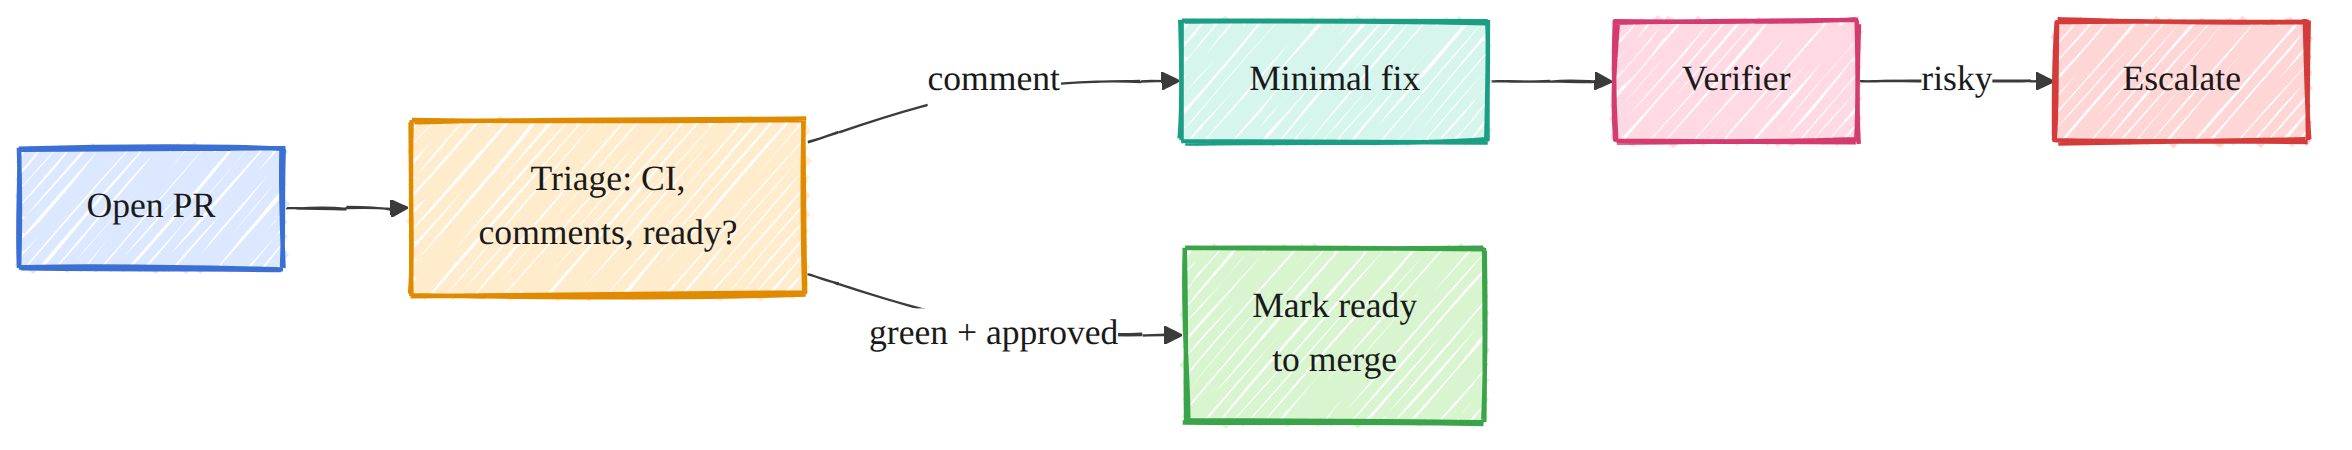

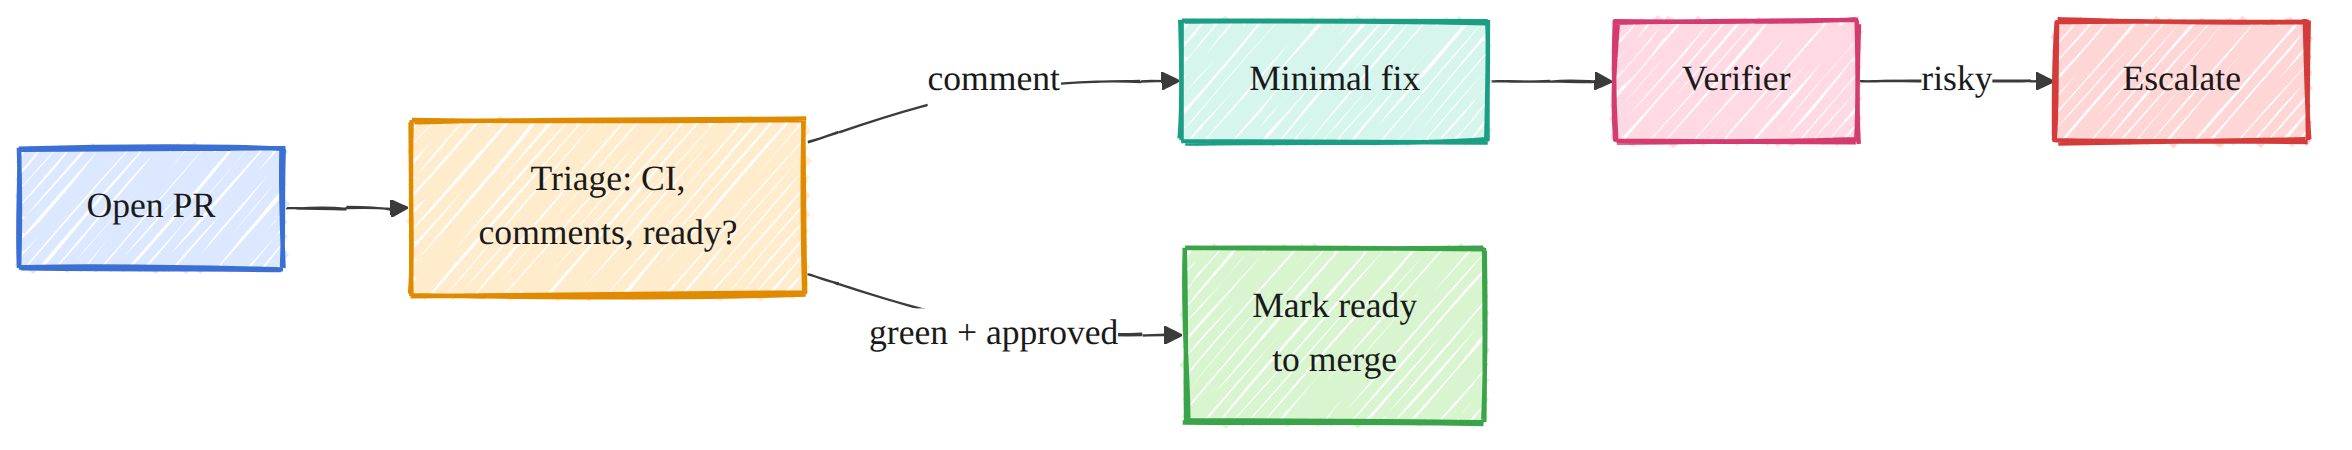

In [1]:
import os
import sys
import time

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, data, agents, loops, plotting, runlog, runtime
from common.llm import LLM

# ── 작업대 구성: PR 30건 ───────────────────────────────────────────
# 30건인 이유는 빨간 PR 이 통계적으로 의미 있는 수만큼 나오면서도 각 PR 마다
# 수정 루프(최대 3회 시도)를 끝까지 돌릴 수 있는 크기이기 때문이다.
N = 30

# 실행 환경 자동 판별 (로컬 vLLM 우선, 없으면 OpenAI API)
rt = runtime.bootstrap()

llm = LLM()
show.head("Setup")
show.show_dict(llm.health(), "엔진 health")

# seed=11 로 고정한다. PR 표본이 실행마다 바뀌면 두 정책을 같은 집합 위에서
# 비교할 수 없고, 오준비판정률의 분모 자체가 흔들린다.
problems = data.load_mbpp_plus(limit=N, seed=11)
show.kv("PR(문제) 수", len(problems))
show.diagram("pr_babysitter", "PR 을 트리아지하고, 빨간 CI 에는 최소 수정을 돌리고, 머지 준비됨은 검증기가 문을 지킨다")

## PR 을 열고 빨간 것을 찾는다

각 PR 은 최초 해답 하나다. 빨간 PR 은 자기 테스트를 통과하지 못하고(빨간 CI), 그래서 돌봄이 필요하다.


In [2]:
# ── PR 30건을 만들고 빨간 것을 골라낸다 ────────────────────────────
# 각 PR = 모델이 낸 최초 해답 하나. temperature=0.0 인 이유는 이 단계가
# 실험의 처치 대상이 아니라 작업대이기 때문이다. 재실행 시 같은 빨간 집합이
# 나와야 두 정책의 비교가 같은 조건 위에 선다.
prs = []
for p in problems:
    code, _ = agents.single_shot(llm, p, temperature=0.0, label="pr")
    # ⚠️ 함정: green_initial 을 모델에게 "이 코드 맞나?" 라고 물어서 정하면
    #    이 노트북이 측정하려는 바로 그 오류가 작업대 구성 단계에 이미
    #    섞여 들어온다. 정답 라벨은 반드시 실행으로 만든다.
    green = agents.grade(p, code)["all_pass"]
    prs.append({"p": p, "code": code, "green_initial": green})

# 초록 PR 은 돌볼 것이 없다. 준비 판정이 틀릴 수 있는 것은 빨간 쪽뿐이다.
red = [pr for pr in prs if not pr["green_initial"]]
show.kv("전체 PR", len(prs))
show.kv("빨간 PR (CI 실패)", len(red))

  전체 PR:                     30
  빨간 PR (CI 실패):             6


## 빨간 PR 을 돌본다: 수정 루프, 그다음 준비 판정

빨간 PR 마다 베이비시터가 수정 루프를 돌린다. 그다음 두 개의 준비 판정 정책이 각각 머지 준비됨을 붙일지 결정한다 — **순진한 방식**(구현자에게 고쳤는지 물어본다) 대 **검증기 게이트 방식**(테스트를 돌린다).


### 검증기가 문을 지키는 전이 — 03번의 제1원칙을 워크플로에 적용하기

여기서부터의 처방은 규칙 하나로 압축된다 — **검사를 실행하지 않고는 상태를 바꾸지 않는다.** "준비됨" 으로 들어가는 전이는 오직 외부의 테스트 실행만이 승인할 수 있다. 누군가의 완료 보고는 승인이 아니며, **구현자 자신의 보고는 특히 아니다.**

이것은 03번이 해답 하나에 적용했던 그 제1원칙을 워크플로 층으로 한 칸 올린 것이다. 거기서의 질문은 "이 답이 옳은가" 였고 여기서의 질문은 "이 PR 이 나아가도 되는가" 이지만, **게이트의 정체는 동일하다 — 주장과 그 주장의 수용 사이에 실제 실행 하나가 서 있는 것.**

아래에서 시험하는 메커니즘은 **같은 PR 집합 위에서의 깨끗한 A/B** 다. 베이비시터가 빨간 PR 마다 수정 루프를 돌린 뒤, 두 정책이 각각 판정한다.

- **순진한 방식** — 구현자에게 자기평가를 요청한다("고쳐졌나?").
- **검증기 게이트 방식** — 테스트를 돌리고 `all_pass` 를 읽는다.

**검증기 게이트의 오준비판정률은 구조상 0 일 수밖에 없다.** 그 게이트가 곧 정답 판정 그 자체이기 때문이다. 그러므로 실제로 측정되는 값은 하나뿐이다 — **테스트를 돌렸다면 여전히 깨졌다고 잡혔을 PR 을 순진한 정책이 얼마나 자주 "준비됨" 이라 부르는가.**

PR 마다 찍히는 세 열을 눈여겨보라. `fixed` 는 정답 판정, `naive_ready` 는 자기보고, `verifier_ready` 는 테스트 게이트다. **`fixed=0` 인데 `naive_ready=1` 인 모든 행이, 순진한 베이비시터라면 그대로 통과시켰을 깨진 PR 이다.**


In [3]:
# ── 두 정책의 A/B: 자기보고 대 테스트 실행 ────────────────────────
# 카운터를 네 개로 나눈 이유는 '준비됨을 몇 건 붙였는가' 와 '그중 몇 건이
# 틀렸는가' 가 서로 다른 질문이기 때문이다. 후자만 세면 게이트가 지나치게
# 보수적이어서 아무것도 통과시키지 않는 경우도 만점으로 보인다.
naive_false_ready = naive_ready = 0
verif_false_ready = verif_ready = 0
fixed = 0
llm.reset_usage()      # 여기서부터의 토큰만 이 패턴의 비용으로 센다
t0 = time.time()
for pr in red:
    p = pr["p"]
    # 01번의 수정 루프를 그대로 재사용한다. 상한 3회도 01번의 경계 그대로다.
    # 베이비시터가 새로 더하는 것은 루프가 아니라 루프 뒤의 게이트다.
    r = loops.self_refine(llm, p, max_attempts=3, use_feedback=True, label="babysit")
    actually_green = r["solved"]     # 정답 판정: 실행 결과다
    fixed += actually_green

    # 순진한 준비 판정: 구현자의 자기평가를 믿는다
    naive_says_ready = agents.self_assess(llm, p, r["code"])
    if naive_says_ready:
        naive_ready += 1
        if not actually_green:
            naive_false_ready += 1

    # 검증기 게이트 준비 판정: 테스트를 돌린다
    verifier_says_ready = agents.grade(p, r["code"])["all_pass"]
    if verifier_says_ready:
        verif_ready += 1
        if not actually_green:
            verif_false_ready += 1   # 구조상 0 이다: 게이트가 곧 그 테스트 실행이다
    print(f"  {p.id:<14} fixed={int(actually_green)} naive_ready={int(naive_says_ready)} verifier_ready={int(verifier_says_ready)}")
elapsed = time.time() - t0

# ⚠️ 함정: 분모는 빨간 PR 수(nr)이지 전체 PR 수가 아니다. 30 으로 나누면
#    같은 실패 2건이 33퍼센트가 아니라 7퍼센트로 보인다. 초록 24건은 애초에
#    판정이 틀릴 수 없는 항목이므로 분모에 넣으면 지표가 희석된다.
nr = len(red)
show.head("빨간 PR 에 대한 베이비시터 결과")
show.metric("빨간 PR", nr)
show.metric("수정 루프가 초록으로 돌린 PR", fixed)
show.metric("순진한 방식의 오준비판정 (준비됨을 붙였으나 여전히 깨짐)", naive_false_ready)
show.metric("검증기 게이트의 오준비판정", verif_false_ready)
naive_fr_rate = naive_false_ready / nr if nr else 0.0
verif_fr_rate = verif_false_ready / nr if nr else 0.0

  mbppplus/398   fixed=1 naive_ready=0 verifier_ready=1
  mbppplus/603   fixed=0 naive_ready=0 verifier_ready=0
  mbppplus/448   fixed=1 naive_ready=0 verifier_ready=1
  mbppplus/773   fixed=1 naive_ready=0 verifier_ready=1
  mbppplus/808   fixed=1 naive_ready=0 verifier_ready=1
  mbppplus/410   fixed=1 naive_ready=0 verifier_ready=1

======================================= 빨간 PR 에 대한 베이비시터 결과 ========================================
  빨간 PR                            6
  수정 루프가 초록으로 돌린 PR                5
  순진한 방식의 오준비판정 (준비됨을 붙였으나 여전히 깨짐) 0
  검증기 게이트의 오준비판정                   0


## 그래프


  오준비판정률: 검증기 게이트 대 순진한 방식
    baseline : 0.0000
    treatment: 0.0000
    delta    : +0.0000  (+nan percent)  [flat, no change]


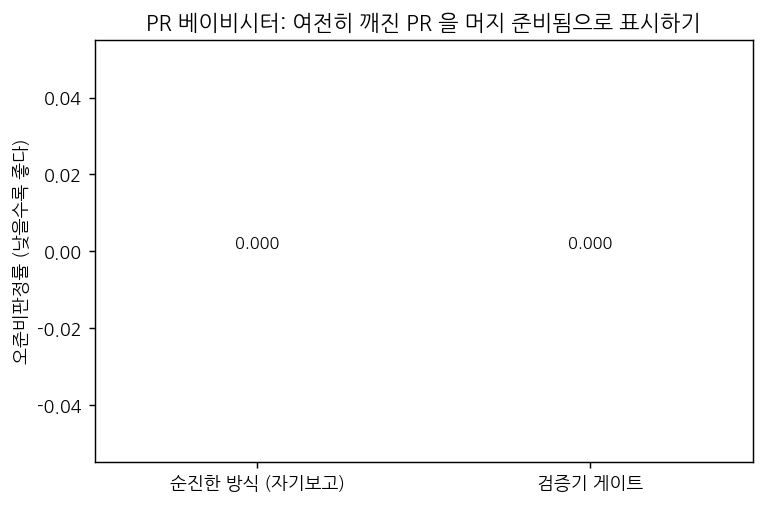

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/13_false_ready.png


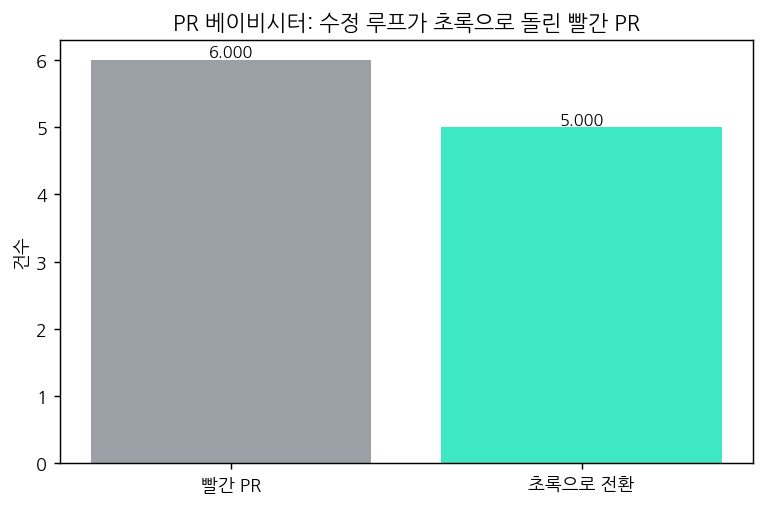

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/13_fix_rate.png
  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/13_pr_babysitter.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (pr-babysitter: fix-proposed, ~13786 tokens)


{'run_id': '2026-08-19T07:38:08Z',
 'pattern': 'pr-babysitter',
 'duration_s': 122.9,
 'items_found': 6,
 'actions_taken': 5,
 'escalations': 1,
 'tokens_estimate': 13786,
 'outcome': 'fix-proposed'}

In [4]:
# ── 두 장의 그래프 ────────────────────────────────────────────────
# 첫 장이 헤드라인(오준비판정률), 둘째 장이 그 헤드라인의 분모를 보여 준다.
# 비율만 그리면 6건 중 2건이라는 표본 크기가 그래프에서 사라진다.
show.compare("오준비판정률: 검증기 게이트 대 순진한 방식", naive_fr_rate, verif_fr_rate, higher_is_better=False)
plotting.ab_bar("13_false_ready", ["순진한 방식 (자기보고)", "검증기 게이트"],
                [naive_fr_rate, verif_fr_rate], "오준비판정률 (낮을수록 좋다)",
                "PR 베이비시터: 여전히 깨진 PR 을 머지 준비됨으로 표시하기")
plotting.ab_bar("13_fix_rate", ["빨간 PR", "초록으로 전환"],
                [nr, fixed], "건수", "PR 베이비시터: 수정 루프가 초록으로 돌린 빨간 PR")

# ⚠️ 함정: fixed 와 오준비판정률을 함께 저장해야 한다. 오준비판정률만 남기면
#    "게이트가 아무것도 통과시키지 않아서 0 이 됐다" 는 경우와 구별되지 않는다.
#    08번이 이 패턴의 비용을 재구성할 때 두 값이 함께 있어야 한다.
runlog.save_metrics("13_pr_babysitter", {"notebook": "13_pr_babysitter", "prs": len(prs), "red": nr,
                                         "provider": llm.provider,   # 한국어판 추가: 어느 백엔드의 수치인지 기록
                                         "model": llm.model,
                                         "fixed": fixed, "naive_false_ready_rate": naive_fr_rate,
                                         "verifier_false_ready_rate": verif_fr_rate, "tokens": llm.usage.total_tokens})
# escalations = 고치지 못한 PR 수. 상한에 걸린 것은 사람에게 넘어가야 할 몫이다.
runlog.log_run(pattern="pr-babysitter", duration_s=elapsed, items_found=nr, actions_taken=fixed,
               escalations=nr - fixed, tokens_estimate=llm.usage.total_tokens, outcome="fix-proposed")

## 이 실행이 실제로 보여 준 것


In [5]:
show.head("이 실행이 실제로 보여 준 것")
print(f"PR {len(prs)}건 중 {nr}건이 빨갰다(CI 실패). 수정 루프가 그중 {fixed}건을 초록으로 돌렸다.")
print(f"구현자의 자기보고를 믿는 순진한 베이비시터는 여전히 깨진 PR {naive_false_ready}건에")
print(f"머지 준비됨을 붙였다 (오준비판정 {naive_fr_rate:.0%}).")
print(f"검증기 게이트를 붙인 베이비시터의 오준비판정은 {verif_false_ready}건 ({verif_fr_rate:.0%})이다.")
print("'준비됨' 이라고 말하기 전에 테스트를 돌리므로 깨진 PR 이 빠져나갈 수 없다.")
print()
print("=> 베이비시터는 빨간 PR 을 고치고, 머지 준비 여부는 실제 테스트 실행에 건다.")
print("   구현자의 말에 걸지 않는다. 루프는 '준비됨' 을 제안할 뿐, 머지는 여전히 사람이 한다.")


========================================= 이 실행이 실제로 보여 준 것 =========================================
PR 30건 중 6건이 빨갰다(CI 실패). 수정 루프가 그중 5건을 초록으로 돌렸다.
구현자의 자기보고를 믿는 순진한 베이비시터는 여전히 깨진 PR 0건에
머지 준비됨을 붙였다 (오준비판정 0%).
검증기 게이트를 붙인 베이비시터의 오준비판정은 0건 (0%)이다.
'준비됨' 이라고 말하기 전에 테스트를 돌리므로 깨진 PR 이 빠져나갈 수 없다.

=> 베이비시터는 빨간 PR 을 고치고, 머지 준비 여부는 실제 테스트 실행에 건다.
   구현자의 말에 걸지 않는다. 루프는 '준비됨' 을 제안할 뿐, 머지는 여전히 사람이 한다.
